#  BERT Fine-Tuning — Classification de News (InShort)
### Devoir N°3 Deep Laerning -  Dakar Institute of Technology (DIT) — Master 2 Intelligence Artificielle
### Réalisé par Alpha Oumar DIALLO

---

**Pipeline complet :**
1. Installation des dépendances
2. Inspection approfondie du dataset
3. Implémentation du `TextClassificationDataset`
4. Chargement du modèle BERT multilingue
5. Fonctions utilitaires (métriques, visualisations, W&B)
6. Entraînement et évaluation

> **Modèle :** `google-bert/bert-base-multilingual-cased`  
> **Tâche :** Classification multi-classe d'articles de presse  
> **Entrée BERT :** `news_headline` + `news_article` concaténés → `text_combined`

##  0. Installation & Imports

In [ ]:
# Installation des dépendances
!pip install transformers datasets wandb seaborn scikit-learn tqdm --quiet

In [7]:
import os
import json
import time
import random
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    PreTrainedTokenizerBase,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from tqdm import tqdm
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# Vérification du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


##  1. Hyperparamètres (CONFIG)

In [43]:
CONFIG = {
    # Modèle
    'model_name':     'google-bert/bert-base-multilingual-cased',
    # max_length : 128 pour titres seuls, 256 pour titre+article concaténés
    # (BERT accepte jusqu'à 512 tokens, mais 256 couvre ~95% des paires)
    'max_length':     256,

    # Données
    'dataset_path':   '/content/inshort_news_data-1 2.csv',  # ← Adaptez ce chemin
    'text_column':    'news_headline',    # Colonne titre
    'article_column': 'news_article',     # Colonne article (concaténé au titre)
    'label_column':   'news_category',
    'val_split':      0.20,

    # Entraînement
    'num_epochs':    4,
    'batch_size':    16,
    'learning_rate': 3e-5,
    'weight_decay':  0.01,
    'warmup_ratio':  0.10,
    'clip_grad':     1.0,

    # Reproductibilité & sauvegarde
    'seed':          42,
    'save_dir':      'best_model',

    # W&B
    'project_wandb': 'bert-classification-inshort-news',
    'run_name':      'bert-multilingual-cased-run1',
}

print(' Configuration chargée.')
for k, v in CONFIG.items():
    print(f'   {k:<20} = {v}')

 Configuration chargée.
   model_name           = google-bert/bert-base-multilingual-cased
   max_length           = 256
   dataset_path         = /content/inshort_news_data-1 2.csv
   text_column          = news_headline
   article_column       = news_article
   label_column         = news_category
   val_split            = 0.2
   num_epochs           = 4
   batch_size           = 16
   learning_rate        = 3e-05
   weight_decay         = 0.01
   warmup_ratio         = 0.1
   clip_grad            = 1.0
   seed                 = 42
   save_dir             = best_model
   project_wandb        = bert-classification-inshort-news
   run_name             = bert-multilingual-cased-run1


---
##  2. Inspection du Dataset

Avant d'entraîner, il est **indispensable** d'analyser le dataset pour :
- Comprendre la distribution des classes (déséquilibre éventuel)
- Choisir la bonne valeur de `max_length`
- Détecter des anomalies ou textes corrompus

### 2.1 — Chargement brut du CSV

In [9]:
# ── Chargement ────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CONFIG['dataset_path'])

print(f"{'═'*60}")
print(f"   INFORMATIONS GÉNÉRALES DU DATASET")
print(f"{'═'*60}")
print(f"  Fichier   : {CONFIG['dataset_path']}")
print(f"  Shape brut: {df_raw.shape}  ({df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes)")
print(f"  Colonnes  : {list(df_raw.columns)}")
print(f"\n  Aperçu des premières lignes :")
df_raw.head()

════════════════════════════════════════════════════════════
   INFORMATIONS GÉNÉRALES DU DATASET
════════════════════════════════════════════════════════════
  Fichier   : /content/inshort_news_data-1 2.csv
  Shape brut: (4817, 4)  (4,817 lignes × 4 colonnes)
  Colonnes  : ['Unnamed: 0', 'news_headline', 'news_article', 'news_category']

  Aperçu des premières lignes :


,Unnamed: 0,news_headline,news_article,news_category
0,0,50-year-old problem of biology solved by Artif...,DeepMind's AI system 'AlphaFold' has been reco...,technology
1,1,Microsoft Teams to stop working on Internet Ex...,Microsoft Teams will stop working on Internet ...,technology
2,2,Hope US won't erect barriers to cooperation: C...,"China, in response to reports of US adding Chi...",technology
3,3,Global smartphone sales in Q3 falls 5.7% to 36...,The global smartphone sales in the third quart...,technology
4,4,EU hoping Biden will clarify US position on di...,The European Union (EU) is hoping that US Pres...,technology


### 2.2 — Nettoyage et statistiques générales

In [10]:
# ── Nettoyage ─────────────────────────────────────────────────────────────────
TEXT_COL    = CONFIG['text_column']
ARTICLE_COL = CONFIG['article_column']
LABEL_COL   = CONFIG['label_column']

df = df_raw[[TEXT_COL, ARTICLE_COL, LABEL_COL]].copy()
n_before = len(df)
df = df.dropna()
df[TEXT_COL]    = df[TEXT_COL].astype(str).str.strip()
df[ARTICLE_COL] = df[ARTICLE_COL].astype(str).str.strip()
df[LABEL_COL]   = df[LABEL_COL].astype(str).str.strip()
df = df[(df[TEXT_COL] != '') & (df[ARTICLE_COL] != '')]  # Retire les lignes vides

# ── Colonne combinée : titre [SEP] article ────────────────────────────────────
# On concatène le titre et l'article avec le token séparateur [SEP] de BERT.
# BERT encode naturellement deux segments distincts grâce à token_type_ids.
# Format : "[titre]. [article]" (le tokenizer ajoute [CLS]/[SEP] automatiquement)
COMBINED_COL = 'text_combined'
df[COMBINED_COL] = df[TEXT_COL] + '. ' + df[ARTICLE_COL]

n_after = len(df)

print(f"{'═'*60}")
print(f"   NETTOYAGE")
print(f"{'═'*60}")
print(f"  Lignes avant nettoyage : {n_before:>6,}")
print(f"  Lignes supprimées      : {n_before - n_after:>6,}  (NaN, vides)")
print(f"  Lignes après nettoyage : {n_after:>6,}")

# ── Nombre de classes ─────────────────────────────────────────────────────────
class_names_raw = sorted(df[LABEL_COL].unique())
num_classes     = len(class_names_raw)

print(f"\n{'═'*60}")
print(f"    NOMBRE TOTAL D'EXEMPLES ET DE CLASSES")
print(f"{'═'*60}")
print(f"  Nombre total d'exemples : {n_after:,}")
print(f"  Nombre de classes       : {num_classes}")
print(f"  Classes détectées :")
for i, cls in enumerate(class_names_raw):
    print(f"    [{i}] {cls}")

════════════════════════════════════════════════════════════
   NETTOYAGE
════════════════════════════════════════════════════════════
  Lignes avant nettoyage :  4,817
  Lignes supprimées      :      0  (NaN, vides)
  Lignes après nettoyage :  4,817

════════════════════════════════════════════════════════════
    NOMBRE TOTAL D'EXEMPLES ET DE CLASSES
════════════════════════════════════════════════════════════
  Nombre total d'exemples : 4,817
  Nombre de classes       : 7
  Classes détectées :
    [0] automobile
    [1] entertainment
    [2] politics
    [3] science
    [4] sports
    [5] technology
    [6] world


### 2.3 — Distribution des classes & détection du déséquilibre

In [11]:
# ── Distribution ──────────────────────────────────────────────────────────────
dist = df[LABEL_COL].value_counts().sort_values(ascending=False)

print(f"{'═'*60}")
print(f"  DISTRIBUTION DES CLASSES")
print(f"{'═'*60}")
print(f"  {'Classe':<22} {'Count':>6}  {'%':>6}  Barre")
print(f"  {'-'*55}")
for cls, cnt in dist.items():
    pct = cnt / n_after * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:<22} {cnt:>6,}  {pct:>5.1f}%  {bar}")

# ── Déséquilibre ──────────────────────────────────────────────────────────────
ratio = dist.max() / dist.min()
print(f"\n  Ratio max/min : {ratio:.2f}x")

if ratio > 2.0:
    print(f"\n    DÉSÉQUILIBRE DÉTECTÉ (ratio = {ratio:.1f}x > 2:1)")
    print(f"   Stratégie retenue :")
    print(f"    1. Split STRATIFIÉ (train_test_split avec stratify=labels)")
    print(f"       → Préserve la distribution originale dans chaque split.")
    print(f"    2. Métrique principale : F1-MACRO")
    print(f"       → Donne le même poids à chaque classe indépendamment")
    print(f"         de sa fréquence (évite le biais vers la classe majoritaire).")
    print(f"    3. Pas de sur-échantillonnage ici (BERT fine-tuning tolère")
    print(f"       un déséquilibre modéré grâce au pré-entraînement).")
    print(f"   Si ratio > 10:1, envisager class_weight dans CrossEntropyLoss.")
else:
    print(f"   Dataset ÉQUILIBRÉ (ratio {ratio:.1f}x ≤ 2:1) — pas d'ajustement nécessaire.")

════════════════════════════════════════════════════════════
  DISTRIBUTION DES CLASSES
════════════════════════════════════════════════════════════
  Classe                  Count       %  Barre
  -------------------------------------------------------
  world                   1,021   21.2%  ██████████
  entertainment             998   20.7%  ██████████
  sports                    856   17.8%  ████████
  technology                751   15.6%  ███████
  politics                  546   11.3%  █████
  science                   389    8.1%  ████
  automobile                256    5.3%  ██

  Ratio max/min : 3.99x

    DÉSÉQUILIBRE DÉTECTÉ (ratio = 4.0x > 2:1)
   Stratégie retenue :
    1. Split STRATIFIÉ (train_test_split avec stratify=labels)
       → Préserve la distribution originale dans chaque split.
    2. Métrique principale : F1-MACRO
       → Donne le même poids à chaque classe indépendamment
         de sa fréquence (évite le biais vers la classe majoritaire).
    3. Pas de sur

In [12]:
# ── Graphique de distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des classes — InShort News Dataset', fontsize=14, fontweight='bold')

# Barplot
colors = plt.cm.Set3.colors[:len(dist)]
bars = axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Nombre d\'exemples par classe', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'exemples')
axes[0].tick_params(axis='x', rotation=40)
for bar, cnt in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Camembert
axes[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion par classe (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution_inspection.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Graphique sauvegardé → class_distribution_inspection.png')

   Graphique sauvegardé → class_distribution_inspection.png


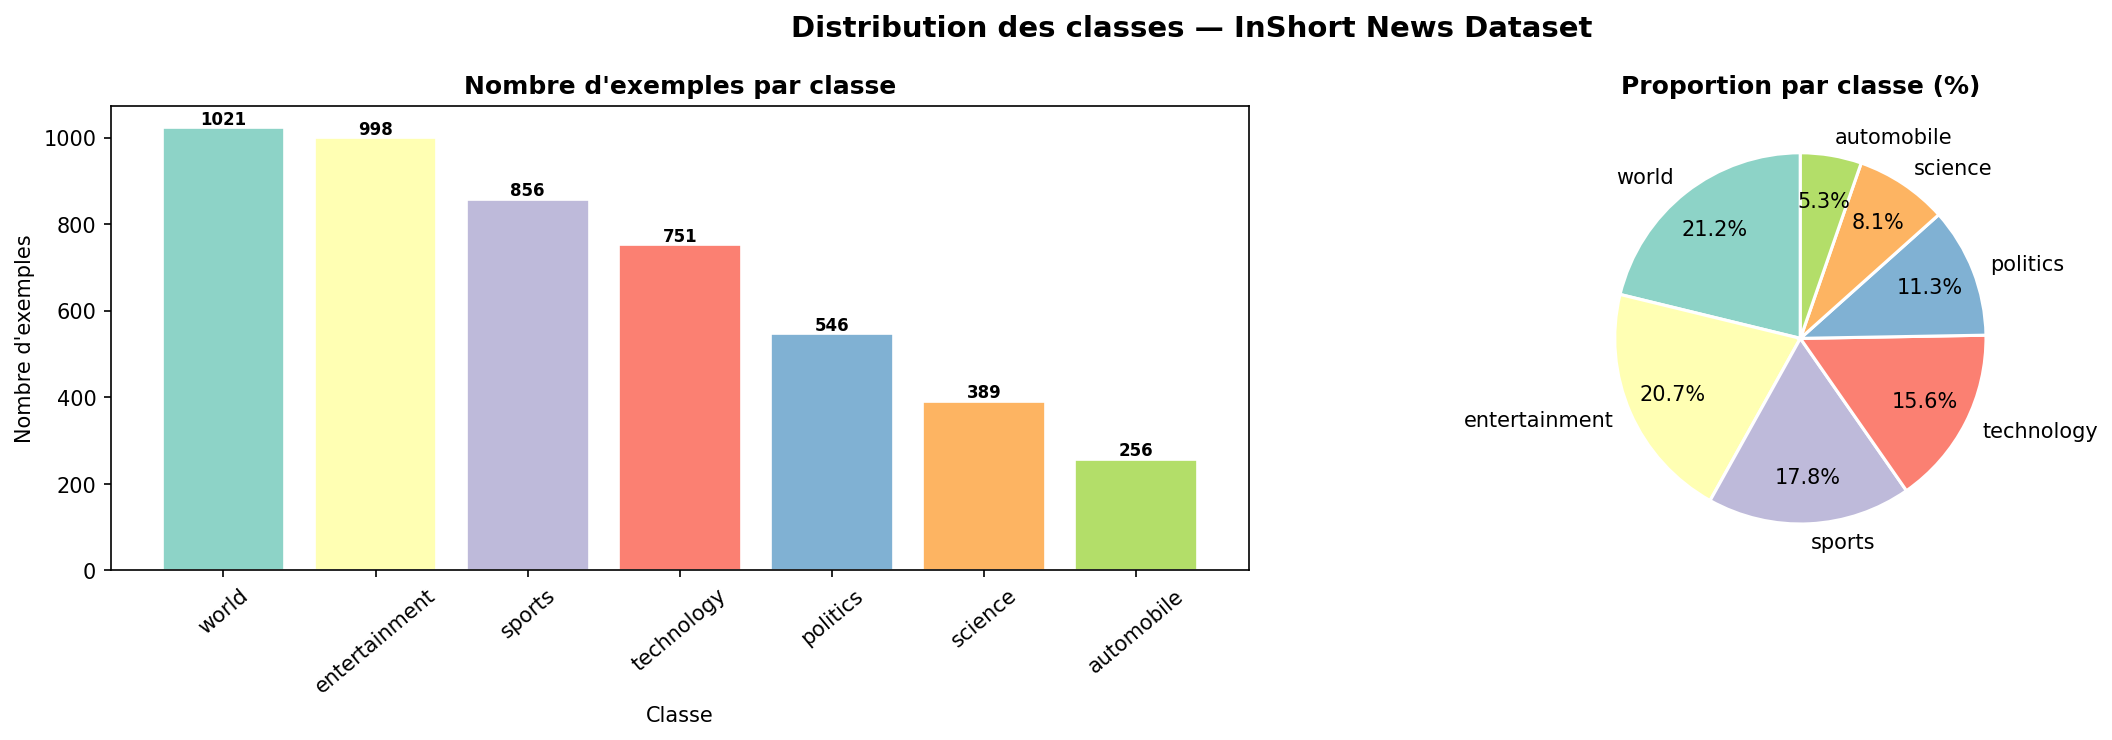

In [13]:
from IPython.display import Image
Image(filename='class_distribution_inspection.png')

### 2.4 — Longueur des textes (en tokens BERT)

In [15]:
# ── Chargement du tokenizer pour mesurer les vraies longueurs BERT ────────────
print('   Chargement du tokenizer pour l\'analyse des longueurs...')
_tokenizer_inspect = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'  Tokenizer chargé | Vocab size : {_tokenizer_inspect.vocab_size:,}\n')

# Calcul des longueurs en TOKENS BERT pour les 3 colonnes
print('   Tokenization des 3 colonnes pour l\'analyse (1-2 min)...')
tok_headline = df[TEXT_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
tok_article  = df[ARTICLE_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
tok_combined = df[COMBINED_COL].apply(
    lambda t: len(_tokenizer_inspect.encode(t, add_special_tokens=True))
)
# On utilise la colonne combinée comme référence principale
token_lengths = tok_combined
word_lengths  = df[COMBINED_COL].str.split().str.len()

print(f"\n{'═'*70}")
print(f"   LONGUEUR DES TEXTES (en tokens BERT)")
print(f"{'═'*70}")
print(f"  {'Métrique':<16} {'Titre':>10}  {'Article':>10}  {'Titre+Article':>14}")
print(f"  {'-'*55}")
for label, s_h, s_a, s_c in [
    ('Minimum',      tok_headline.min(),              tok_article.min(),              tok_combined.min()),
    ('Maximum',      tok_headline.max(),              tok_article.max(),              tok_combined.max()),
    ('Moyenne',      tok_headline.mean(),             tok_article.mean(),             tok_combined.mean()),
    ('Médiane (P50)',tok_headline.median(),           tok_article.median(),           tok_combined.median()),
    ('P90',          tok_headline.quantile(0.90),     tok_article.quantile(0.90),     tok_combined.quantile(0.90)),
    ('P95',          tok_headline.quantile(0.95),     tok_article.quantile(0.95),     tok_combined.quantile(0.95)),
    ('P99',          tok_headline.quantile(0.99),     tok_article.quantile(0.99),     tok_combined.quantile(0.99)),
]:
    print(f"  {label:<16} {s_h:>10.0f}  {s_a:>10.0f}  {s_c:>14.0f}")

p95_tokens = tok_combined.quantile(0.95)
print(f"\n  Recommandation max_length (basé sur Titre+Article) :")
print(f"     P95 combiné = {p95_tokens:.0f} tokens → CONFIG['max_length'] = {CONFIG['max_length']}")
if CONFIG['max_length'] >= p95_tokens:
    pct_covered = (tok_combined <= CONFIG['max_length']).mean() * 100
    print(f"      Couvre {pct_covered:.1f}% des paires (titre+article) sans troncature.")
else:
    pct_truncated = (tok_combined > CONFIG['max_length']).mean() * 100
    print(f"       {pct_truncated:.1f}% des paires seront tronquées à {CONFIG['max_length']} tokens.")
    print(f"     → Envisager max_length = {int(p95_tokens) + 4} (arrondi au multiple de 4).")
    print(f"       Note : BERT accepte jusqu\'à 512 tokens max.")

   Chargement du tokenizer pour l'analyse des longueurs...
  Tokenizer chargé | Vocab size : 119,547

   Tokenization des 3 colonnes pour l'analyse (1-2 min)...

══════════════════════════════════════════════════════════════════════
   LONGUEUR DES TEXTES (en tokens BERT)
══════════════════════════════════════════════════════════════════════
  Métrique              Titre     Article   Titre+Article
  -------------------------------------------------------
  Minimum                  10          63              77
  Maximum                  31         144             162
  Moyenne                  19          88             106
  Médiane (P50)            19          87             105
  P90                      24         101             122
  P95                      25         106             128
  P99                      28         115             138

  Recommandation max_length (basé sur Titre+Article) :
     P95 combiné = 128 tokens → CONFIG['max_length'] = 256
      Couvre 100.0%

In [16]:
# ── Histogramme des longueurs (3 colonnes superposées) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des longueurs de texte (tokens BERT)', fontsize=14, fontweight='bold')

# Histogramme superposé : titre / article / combiné
axes[0].hist(tok_headline, bins=50, color='steelblue', edgecolor='white', alpha=0.6, label='Titre seul')
axes[0].hist(tok_article,  bins=50, color='salmon',    edgecolor='white', alpha=0.6, label='Article seul')
axes[0].hist(tok_combined, bins=50, color='mediumpurple', edgecolor='white', alpha=0.6, label='Titre + Article')
axes[0].axvline(tok_combined.mean(),          color='black',  linestyle='--', linewidth=2, label=f'Moy. combiné ({tok_combined.mean():.0f})')
axes[0].axvline(tok_combined.quantile(0.95),  color='red',    linestyle='--', linewidth=2, label=f'P95 combiné ({tok_combined.quantile(0.95):.0f})')
axes[0].axvline(CONFIG['max_length'],         color='green',  linestyle='-',  linewidth=2, label=f'max_length ({CONFIG["max_length"]})')
axes[0].set_title('Longueurs en tokens BERT', fontweight='bold')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Boxplot par classe — colonne combinée
df_plot = df.copy()
df_plot['tok_combined'] = tok_combined.values
class_order = df[LABEL_COL].value_counts().index.tolist()
sns.boxplot(data=df_plot, x=LABEL_COL, y='tok_combined', ax=axes[1],
            order=class_order, palette='Set3')
axes[1].axhline(CONFIG['max_length'], color='red', linestyle='--', linewidth=1.5,
                label=f'max_length={CONFIG["max_length"]}')
axes[1].set_title('Longueur Titre+Article par classe', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de tokens BERT (combiné)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Graphique sauvegardé → token_length_distribution.png')

/tmp/ipykernel_7516/3698456577.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=LABEL_COL, y='tok_combined', ax=axes[1],


   Graphique sauvegardé → token_length_distribution.png


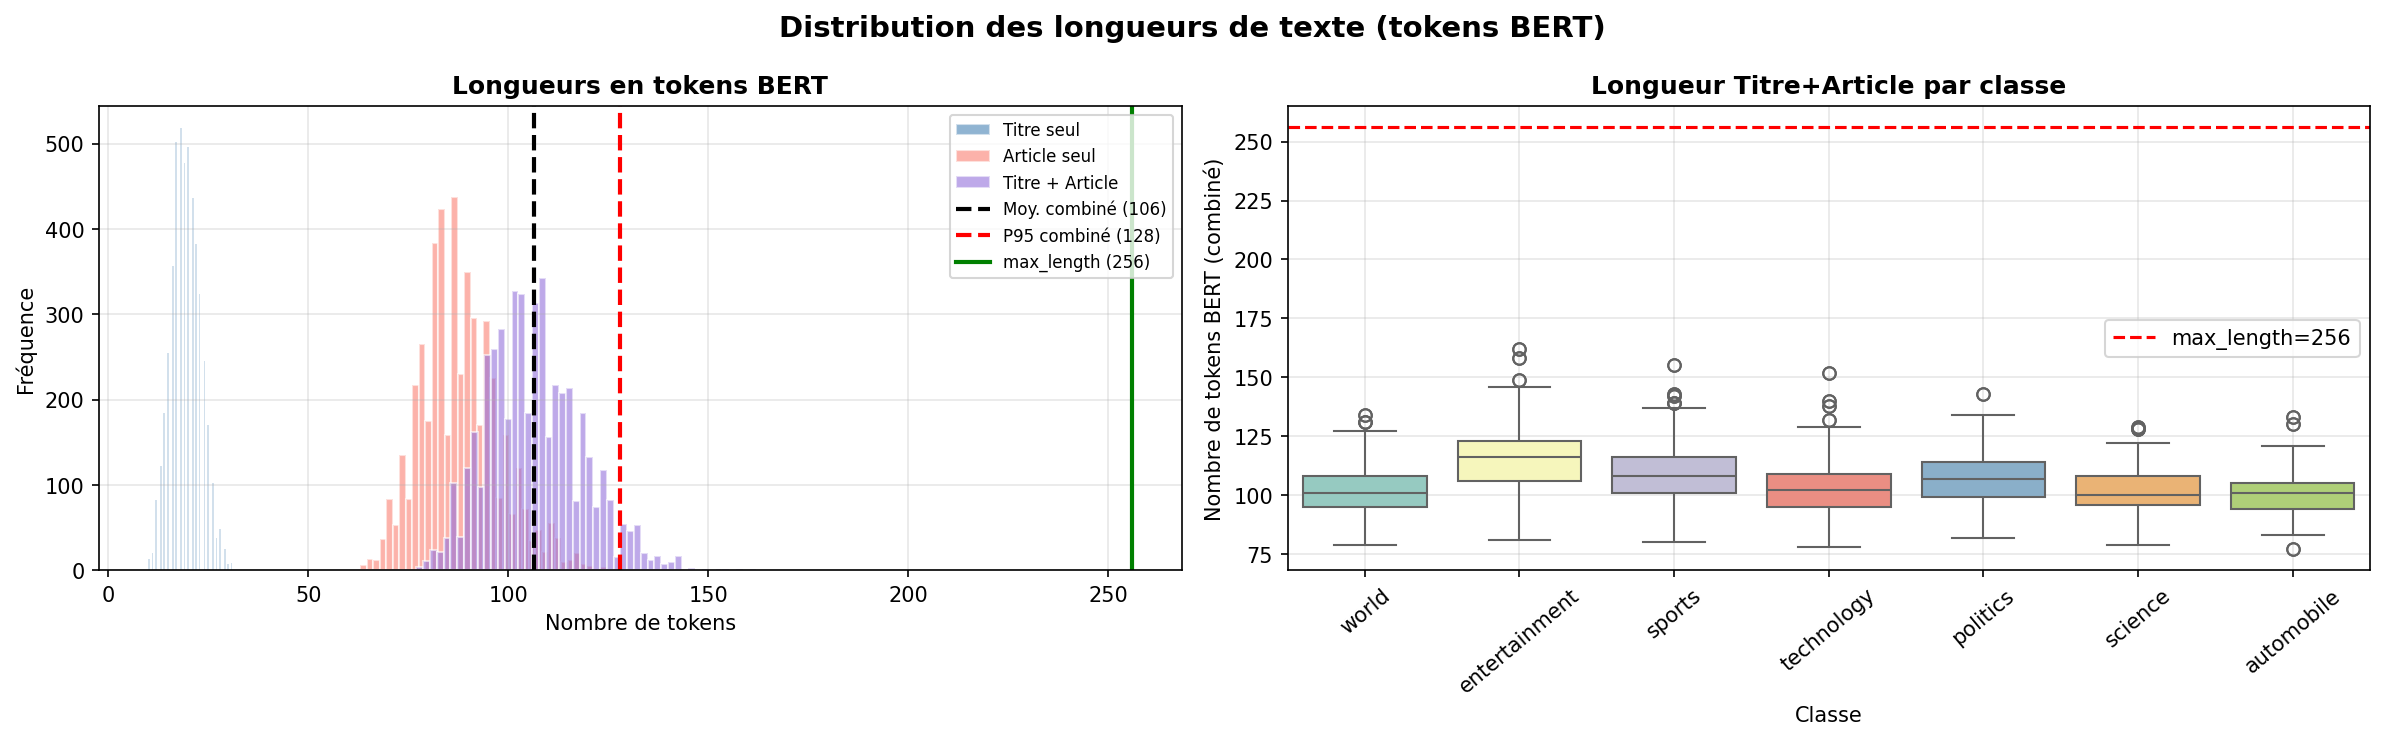

In [17]:
from IPython.display import Image
Image(filename='/content/token_length_distribution.png')

### 2.5 — Affichage de 5 exemples par classe

In [47]:
# ── 5 exemples aléatoires ─────────────────────────────────────────────────────
print(f"{'═'*70}")
print(f"   EXEMPLES DE TEXTES AVEC LEURS LABELS (Titre + Article)")
print(f"{'═'*70}")

sample_global = df.sample(n=min(5, len(df)), random_state=CONFIG['seed'])
print(f"\n  ── 5 exemples aléatoires ──")
for i, (_, row) in enumerate(sample_global.iterrows(), 1):
    headline = row[TEXT_COL]
    article  = row[ARTICLE_COL]
    combined = row[COMBINED_COL]
    label    = row[LABEL_COL]
    n_tok_h  = len(_tokenizer_inspect.encode(headline, add_special_tokens=True))
    n_tok_a  = len(_tokenizer_inspect.encode(article,  add_special_tokens=True))
    n_tok_c  = len(_tokenizer_inspect.encode(combined, add_special_tokens=True))
    print(f"\n   Exemple {i} ── Label : {label}")
    print(f"   Titre   ({n_tok_h:>3} tokens) : {headline}")
    print(f"   Article ({n_tok_a:>3} tokens) : {article[:120]}{'...' if len(article) > 120 else ''}")
    print(f"   Combiné ({n_tok_c:>3} tokens) → entrée BERT")

# 1 exemple par classe
print(f"\n{'═'*70}")
print(f"  ── 1 exemple par classe ──")
for cls in class_names_raw:
    subset = df[df[LABEL_COL] == cls]
    row    = subset.sample(n=1, random_state=CONFIG['seed']).iloc[0]
    n_tok  = len(_tokenizer_inspect.encode(row[COMBINED_COL], add_special_tokens=True))
    print(f"\n  [{cls:<20}] ({n_tok} tokens combinés)")
    print(f"    Titre   : {row[TEXT_COL]}")
    print(f"    Article : {row[ARTICLE_COL][:100]}{'...' if len(row[ARTICLE_COL]) > 100 else ''}")

══════════════════════════════════════════════════════════════════════
   EXEMPLES DE TEXTES AVEC LEURS LABELS (Titre + Article)
══════════════════════════════════════════════════════════════════════

  ── 5 exemples aléatoires ──

   Exemple 1 ── Label : science
   Titre   ( 16 tokens) : Nobel Prize winner develops COVID-19 test that uses phone camera
   Article ( 92 tokens) : UC Berkeley and Gladstone Institutes' scientists claim to have developed a CRISPR-based COVID-19 diagnostic test that us...
   Combiné (107 tokens) → entrée BERT

   Exemple 2 ── Label : entertainment
   Titre   ( 21 tokens) : My kids got messages telling them to kill themselves: Kanika on COVID-19 controversy
   Article (109 tokens) : Singer Kanika Kapoor, speaking about controversy around her COVID-19 diagnosis, told Times of India, "When I travelled t...
   Combiné (129 tokens) → entrée BERT

   Exemple 3 ── Label : science
   Titre   ( 21 tokens) : How did a dosing error lead to Oxford vaccine's 90% effectiv

### 2.6 — Résumé de l'inspection

In [48]:
# ── Résumé synthétique ────────────────────────────────────────────────────────
pct_covered   = (tok_combined <= CONFIG['max_length']).mean() * 100
pct_truncated = 100 - pct_covered

print(f"{'═'*65}")
print(f"   RÉSUMÉ DE L'INSPECTION DU DATASET")
print(f"{'═'*65}")
print(f"  Exemples totaux           : {n_after:,}")
print(f"  Nombre de classes         : {num_classes}")
print(f"  Colonne d\'entrée BERT     : {COMBINED_COL}  ({TEXT_COL} + {ARTICLE_COL})")
print(f"  Moy. tokens (titre seul)  : {tok_headline.mean():.1f}")
print(f"  Moy. tokens (article seul): {tok_article.mean():.1f}")
print(f"  Moy. tokens (combiné)     : {tok_combined.mean():.1f}")
print(f"  P95  tokens (combiné)     : {tok_combined.quantile(0.95):.0f}")
print(f"  max_length retenu         : {CONFIG['max_length']}  → couvre {pct_covered:.1f}% ({pct_truncated:.1f}% tronqués)")
print(f"  Ratio déséquilibre        : {ratio:.1f}x")
print(f"  Stratégie split           : stratifié 80/20")
print(f"  Métrique principale       : F1-macro")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
   RÉSUMÉ DE L'INSPECTION DU DATASET
═════════════════════════════════════════════════════════════════
  Exemples totaux           : 4,817
  Nombre de classes         : 7
  Colonne d'entrée BERT     : text_combined  (news_headline + news_article)
  Moy. tokens (titre seul)  : 19.4
  Moy. tokens (article seul): 88.1
  Moy. tokens (combiné)     : 106.4
  P95  tokens (combiné)     : 128
  max_length retenu         : 256  → couvre 100.0% (0.0% tronqués)
  Ratio déséquilibre        : 4.0x
  Stratégie split           : stratifié 80/20
  Métrique principale       : F1-macro
═════════════════════════════════════════════════════════════════


---
##  3. Dataset PyTorch — `dataset.py`

In [49]:
class TextClassificationDataset(Dataset):
    """
    Dataset PyTorch pour la classification de texte avec BERT.

    Tokenize chaque texte à l'initialisation, gère le padding jusqu'à
    `max_length` et renvoie les masques d'attention nécessaires à BERT.

    Args:
        texts        (List[str]): Textes bruts à classer.
        labels       (List[int]): Labels entiers correspondants (0, 1, 2 …).
        tokenizer    (PreTrainedTokenizerBase): Tokenizer HuggingFace.
        max_length   (int): Longueur maximale de séquence (en tokens).
    """

    def __init__(
        self,
        texts: List[str],
        labels: List[int],
        tokenizer: PreTrainedTokenizerBase,
        max_length: int = 128,
    ) -> None:
        self.texts      = [str(t).strip() for t in texts]
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        """Retourne le nombre total d'exemples dans le dataset."""
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        """
        Tokenize et retourne le i-ème exemple sous forme de tenseurs PyTorch.

        Retourne un dict contenant :
            - input_ids      (LongTensor [max_length])
            - attention_mask (LongTensor [max_length]) : 1=token réel, 0=padding
            - label          (LongTensor [])           : Label entier de la classe

        Note : Le masque d'attention est INDISPENSABLE pour BERT — sans lui,
        le modèle traite les tokens de padding comme du contenu réel.
        """
        text  = self.texts[idx]
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',       # Remplit jusqu'à max_length avec [PAD]
            truncation=True,            # Tronque les textes plus longs
            return_attention_mask=True, # CRITIQUE : renvoyer le masque
            return_tensors='pt',        # Tenseurs PyTorch directement
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # [max_length]
            'attention_mask': encoding['attention_mask'].squeeze(0),  # [max_length]
            'label':          torch.tensor(label, dtype=torch.long),  # scalaire
        }

    def get_text(self, idx: int) -> str:
        """Retourne le texte brut à l'indice `idx` (pour le débogage)."""
        return self.texts[idx]

    def get_label(self, idx: int) -> int:
        """Retourne le label entier à l'indice `idx`."""
        return int(self.labels[idx])

    def __repr__(self) -> str:
        return (
            f'TextClassificationDataset('
            f'n_samples={len(self)}, '
            f'max_length={self.max_length}, '
            f'n_classes={len(set(self.labels))})'
        )

print(' TextClassificationDataset défini.')

 TextClassificationDataset défini.


---
##  4. Chargement du modèle BERT — `model.py`

In [50]:
DEFAULT_MODEL    = 'google-bert/bert-base-multilingual-cased'
DEFAULT_SAVE_DIR = 'best_model'


def load_tokenizer(model_name: str = DEFAULT_MODEL) -> AutoTokenizer:
    """
    Charge le tokenizer BERT multilingue depuis HuggingFace Hub.
    """
    print(f'    Téléchargement du tokenizer : {model_name}')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(f'   Tokenizer chargé | Vocab size : {tokenizer.vocab_size:,}')
    return tokenizer


def load_model(
    num_classes: int,
    model_name: str = DEFAULT_MODEL,
) -> AutoModelForSequenceClassification:
    """
    Charge BERT pré-entraîné avec une tête de classification linéaire.

    Architecture : BertModel (encodeur) → Dropout → Linear(hidden_size, num_classes)

    Note: `ignore_mismatched_sizes=True` est nécessaire car la tête de
    classification remplace la tête MLM du modèle pré-entraîné.
    """
    print(f'    Chargement du modèle BERT : {model_name}')
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,  # Remplace la tête MLM → classification
    )
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'   Modèle chargé')
    print(f'     Paramètres totaux       : {total_params:,}')
    print(f'     Paramètres entraînables : {trainable_params:,}')
    print(f'     Nombre de classes       : {num_classes}')
    return model


def save_model(
    model: AutoModelForSequenceClassification,
    tokenizer: AutoTokenizer,
    class_names: list,
    save_dir: str = DEFAULT_SAVE_DIR,
) -> None:
    """
    Sauvegarde le modèle, le tokenizer et le mapping des classes.
    """
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    class_path = os.path.join(save_dir, 'class_names.json')
    with open(class_path, 'w', encoding='utf-8') as f:
        json.dump(class_names, f, ensure_ascii=False, indent=2)
    print(f'   Checkpoint sauvegardé → {save_dir}/')
    print(f'     Classes : {class_names}')


def load_saved_model(save_dir: str = DEFAULT_SAVE_DIR) -> tuple:
    """
    Recharge un modèle fine-tuné et son tokenizer depuis un répertoire.
    """
    if not os.path.isdir(save_dir):
        raise FileNotFoundError(
            f"Le répertoire '{save_dir}' est introuvable. "
            'Veuillez d\'abord entraîner le modèle.'
        )
    tokenizer   = AutoTokenizer.from_pretrained(save_dir)
    model       = AutoModelForSequenceClassification.from_pretrained(save_dir)
    class_path  = os.path.join(save_dir, 'class_names.json')
    with open(class_path, 'r', encoding='utf-8') as f:
        class_names = json.load(f)
    model.eval()
    print(f"   Modèle rechargé depuis '{save_dir}/'")
    print(f'     Classes ({len(class_names)}) : {class_names}')
    return model, tokenizer, class_names


print(' Fonctions model.py définies.')

 Fonctions model.py définies.


---
##  5. Fonctions Utilitaires — `utils.py`

In [51]:
# ──────────────────────────────────────────────────────────────────────────────
# 5.1 Reproductibilité
# ──────────────────────────────────────────────────────────────────────────────

def set_seed(seed: int = 42) -> None:
    """
    Fixe toutes les sources d'aléatoire (Python, NumPy, PyTorch, cuDNN)
    pour garantir la reproductibilité des expériences.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f'🌱 Seed fixée à {seed} — résultats reproductibles.')


# ──────────────────────────────────────────────────────────────────────────────
# 5.2 Métriques
# ──────────────────────────────────────────────────────────────────────────────

def compute_metrics(
    y_true: List[int],
    y_pred: List[int],
    class_names: Optional[List[str]] = None,
    verbose: bool = False,
) -> Dict[str, float]:
    """
    Calcule accuracy et F1-score macro.

    Note : F1-macro donne le même poids à chaque classe, indépendamment
    de sa fréquence — métrique appropriée pour les datasets déséquilibrés.
    """
    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    if verbose and class_names:
        report = classification_report(
            y_true, y_pred, target_names=class_names, zero_division=0
        )
        print(f'\n Rapport de classification :\n{report}')
    return {'accuracy': float(acc), 'f1_macro': float(f1_macro)}


# ──────────────────────────────────────────────────────────────────────────────
# 5.3 Visualisations
# ──────────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(
    y_true: List[int],
    y_pred: List[int],
    class_names: List[str],
    save_path: str = 'confusion_matrix.png',
    title: str = 'Matrice de Confusion — BERT Fine-tuning',
) -> str:
    """Génère et sauvegarde la matrice de confusion sous forme de heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 1.2),
                                    max(6, len(class_names))))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, linecolor='white', ax=ax,
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Vrai Label', fontsize=11)
    ax.set_xlabel('Label Prédit', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'   Matrice de confusion → {save_path}')
    return os.path.abspath(save_path)


def plot_learning_curves(
    history: Dict[str, List[float]],
    save_path: str = 'learning_curves.png',
) -> str:
    """Trace les courbes de loss et d'accuracy par epoch."""
    epochs = range(1, len(history['train_loss']) + 1)
    has_f1 = 'val_f1' in history and len(history['val_f1']) > 0
    n_plots = 3 if has_f1 else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    fig.suptitle(
        'Courbes d\'apprentissage — BERT Fine-tuning (InShort News)',
        fontsize=13, fontweight='bold', y=1.02
    )
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=5)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',   linewidth=2, markersize=5)
    axes[0].set_title('Cross-Entropy Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_accuracy'], 'b-o', label='Train', linewidth=2, markersize=5)
    axes[1].plot(epochs, history['val_accuracy'],   'r-o', label='Val',   linewidth=2, markersize=5)
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    if has_f1:
        axes[2].plot(epochs, history['val_f1'], 'g-o', label='Val F1-macro', linewidth=2, markersize=5)
        axes[2].set_title('F1-Score Macro (val)', fontweight='bold')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1-macro')
        axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'   Courbes d\'apprentissage → {save_path}')
    return os.path.abspath(save_path)


def plot_class_distribution(
    labels: List[int],
    class_names: List[str],
    title: str = 'Distribution des classes',
    save_path: str = 'class_distribution.png',
) -> str:
    """Trace la distribution des classes dans le dataset."""
    counts = [labels.count(i) for i in range(len(class_names))]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(class_names, counts, color=plt.cm.Set3.colors[:len(class_names)])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Classe'); ax.set_ylabel('Nombre d\'exemples')
    ax.tick_params(axis='x', rotation=30)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'   Distribution des classes → {save_path}')
    return os.path.abspath(save_path)


# ──────────────────────────────────────────────────────────────────────────────
# 5.4 Weights & Biases
# ──────────────────────────────────────────────────────────────────────────────

def init_wandb(project_name: str, config: dict, run_name: str = None):
    """Initialise un run Weights & Biases."""
    run = wandb.init(
        project=project_name, name=run_name, config=config,
        tags=['bert', 'nlp', 'classification', 'fine-tuning', 'master2', 'DIT'],
    )
    print(f'   W&B initialisé → {run.url}')
    return run


def log_epoch_metrics(
    epoch, train_loss, val_loss, train_acc, val_acc, val_f1, lr
) -> None:
    """Logue les métriques d'une epoch sur W&B."""
    wandb.log(
        {'epoch': epoch, 'train/loss': train_loss, 'val/loss': val_loss,
         'train/accuracy': train_acc, 'val/accuracy': val_acc,
         'val/f1_macro': val_f1, 'train/lr': lr},
        step=epoch,
    )


def log_confusion_matrix_wandb(y_true, y_pred, class_names) -> None:
    """Logue la matrice de confusion interactive sur W&B."""
    wandb.log({'val/confusion_matrix': wandb.plot.confusion_matrix(
        probs=None, y_true=y_true, preds=y_pred,
        class_names=class_names, title='Matrice de Confusion (validation)',
    )})


def log_image_wandb(key: str, image_path: str, caption: str = '') -> None:
    """Logue une image sur W&B."""
    wandb.log({key: wandb.Image(image_path, caption=caption)})


def log_final_summary(
    best_val_loss, best_val_acc, best_val_f1, class_names
) -> None:
    """Logue le résumé final du run sur W&B."""
    wandb.run.summary.update({
        'best/val_loss': best_val_loss, 'best/val_accuracy': best_val_acc,
        'best/val_f1_macro': best_val_f1, 'n_classes': len(class_names),
        'classes': ', '.join(class_names),
    })
    print(
        f'\n   Résumé W&B enregistré :\n'
        f'     best_val_loss = {best_val_loss:.4f}\n'
        f'     best_val_acc  = {best_val_acc:.4f}\n'
        f'     best_val_f1   = {best_val_f1:.4f}'
    )


print('Fonctions utils.py définies.')

Fonctions utils.py définies.


---
## 6. Entraînement — `train.py`

### 6.1 — Chargement et préparation des données

In [52]:
def load_and_inspect_data(
    data_path: str,
    text_col: str,
    article_col: str,
    label_col: str,
) -> tuple:
    """
    Charge le CSV, concatène titre + article, inspecte la distribution
    des classes et encode les labels.

    La colonne d'entrée BERT = text_col + '. ' + article_col.
    BERT encode les deux segments séparément grâce aux token_type_ids.

    Returns:
        tuple: (texts_combined, labels_int, label_encoder, class_names)
    """
    print(f"\n{'═'*60}")
    print(f'   CHARGEMENT DU DATASET')
    print(f"{'═'*60}")

    df_local = pd.read_csv(data_path)
    print(f'  Fichier    : {data_path}')
    print(f'  Shape brut : {df_local.shape}')

    df_local = df_local[[text_col, article_col, label_col]].dropna()
    df_local[text_col]    = df_local[text_col].astype(str).str.strip()
    df_local[article_col] = df_local[article_col].astype(str).str.strip()
    df_local[label_col]   = df_local[label_col].astype(str).str.strip()
    df_local = df_local[(df_local[text_col] != '') & (df_local[article_col] != '')]
    print(f'  Après nettoyage : {len(df_local):,} exemples')

    # ── Concaténation titre + article ─────────────────────────────────────────
    # Format : "[titre]. [article]" → BERT tokenise avec [CLS] titre [SEP] article [SEP]
    df_local['text_combined'] = df_local[text_col] + '. ' + df_local[article_col]
    print(f'  Colonne combinée créée : text_combined = {text_col} + ". " + {article_col}')

    # Distribution
    print(f'\n   Distribution des classes :')
    dist_local = df_local[label_col].value_counts()
    for cls, cnt in dist_local.items():
        pct = cnt / len(df_local) * 100
        bar = '█' * int(pct / 2)
        print(f'    {cls:<20} {cnt:>5} ({pct:5.1f}%) {bar}')

    ratio_local = dist_local.max() / dist_local.min()
    if ratio_local > 2.0:
        print(f'\n    Déséquilibre détecté (ratio max/min = {ratio_local:.1f}x)')
        print(f'     → Stratégie : split stratifié + F1-macro comme métrique principale')

    # Longueurs approximatives (en mots)
    len_h = df_local[text_col].str.split().str.len()
    len_a = df_local[article_col].str.split().str.len()
    len_c = df_local['text_combined'].str.split().str.len()
    print(f'\n   Longueur approx. (mots) :')
    print(f'    Titre seul   → moy={len_h.mean():.0f}, P95={len_h.quantile(0.95):.0f}')
    print(f'    Article seul → moy={len_a.mean():.0f}, P95={len_a.quantile(0.95):.0f}')
    print(f'    Combiné      → moy={len_c.mean():.0f}, P95={len_c.quantile(0.95):.0f}  ← référence pour max_length')

    # Exemples
    print(f'\n   5 exemples (titre + article) :')
    for i in range(min(5, len(df_local))):
        lbl  = df_local[label_col].iloc[i]
        head = df_local[text_col].iloc[i]
        art  = df_local[article_col].iloc[i][:80]
        print(f'    [{lbl:<12}] Titre: {head[:60]}...')
        print(f'    {"":<14}  Art  : {art}...')

    # Encodage des labels
    le = LabelEncoder()
    labels_int  = le.fit_transform(df_local[label_col].values)
    class_names = list(le.classes_)
    texts_combined = df_local['text_combined'].values.tolist()

    print(f'\n    Mapping label → indice :')
    for idx, name in enumerate(class_names):
        print(f'    {idx} → {name}')

    return texts_combined, labels_int, le, class_names


print(' load_and_inspect_data défini.')

 load_and_inspect_data défini.


### 6.2 — Boucle d'entraînement et d'évaluation

In [53]:
def train_epoch(
    model, loader, optimizer, scheduler, criterion, device, epoch_num
) -> tuple:
    """
    Effectue une epoch complète d'entraînement.

    Procédure par batch :
        1. Transfert des tenseurs sur `device`.
        2. Zero_grad pour effacer les gradients accumulés.
        3. Forward pass (logits via BERT).
        4. Calcul de la loss (CrossEntropyLoss).
        5. Backward pass (calcul des gradients).
        6. Gradient clipping (évite l'explosion du gradient).
        7. Mise à jour des paramètres (optimizer.step).
        8. Mise à jour du scheduler.

    Returns:
        tuple: (avg_loss, accuracy, all_preds, all_labels)
    """
    model.train()  # ← Active dropout
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(
        loader, desc=f'   Epoch {epoch_num} [Train]', leave=False, unit='batch'
    )

    for step, batch in enumerate(pbar):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits  # [batch_size, num_classes]

        loss = criterion(logits, labels_b)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['clip_grad'])
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=1).detach().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels_b.detach().cpu().tolist())

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
        # wandb.log({'batch/train_loss': loss.item(), 'batch/step': step})

    avg_loss = total_loss / len(loader)
    metrics  = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics['accuracy'], all_preds, all_labels


def eval_epoch(
    model, loader, criterion, device, epoch_num
) -> tuple:
    """
    Évalue le modèle sans mise à jour des gradients.

    Points critiques :
        - model.eval()    : désactive dropout.
        - torch.no_grad() : désactive le graphe de calcul → 3-4× plus rapide.

    Returns:
        tuple: (avg_loss, accuracy, f1_macro, all_preds, all_labels)
    """
    model.eval()  # ← Désactive dropout
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(
        loader, desc=f'   Epoch {epoch_num} [Val  ]', leave=False, unit='batch'
    )

    with torch.no_grad():  # ← Pas de gradient
        for batch in pbar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels_b)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).detach().cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels_b.detach().cpu().tolist())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    metrics  = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics['accuracy'], metrics['f1_macro'], all_preds, all_labels


print(' Fonctions train_epoch et eval_epoch définies.')

 Fonctions train_epoch et eval_epoch définies.


### 6.3 — Lancement de l'entraînement

In [54]:
# ── Connexion W&B ─────────────────────────────────────────────────────────────
# Décommentez la ligne suivante si vous n'avez pas encore configuré W&B :
# wandb.login()

t_start = time.time()
print(f"\n{'═'*60}")
print(f'   BERT FINE-TUNING — InShort News Classification')
print(f'   Dakar Institute of Technology (DIT) — Master 2 IA')
print(f"{'═'*60}")

# ── Seed & device ─────────────────────────────────────────────────────────────
set_seed(CONFIG['seed'])
print(f'\n    Device : {device}')

# ── W&B ───────────────────────────────────────────────────────────────────────
run = init_wandb(CONFIG['project_wandb'], CONFIG, CONFIG['run_name'])

# ── Données ───────────────────────────────────────────────────────────────────
texts, labels, label_encoder, class_names = load_and_inspect_data(
    CONFIG['dataset_path'],
    CONFIG['text_column'],
    CONFIG['article_column'],
    CONFIG['label_column'],
)
CONFIG['num_classes'] = len(class_names)
CONFIG['class_names'] = class_names
wandb.config.update({'num_classes': len(class_names), 'class_names': class_names})

# Graphique distribution
dist_path = plot_class_distribution(
    list(labels), class_names, save_path='class_distribution.png'
)
log_image_wandb('data/class_distribution', dist_path, 'Distribution des classes')

# ── Split stratifié 80/20 ─────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=CONFIG['val_split'],
    random_state=CONFIG['seed'],
    stratify=labels,  # Préserve la distribution originale
)
print(f'\n   Split : {len(X_train):,} train | {len(X_val):,} val')

# ── Tokenizer & Datasets ──────────────────────────────────────────────────────
print(f'\n   Chargement du tokenizer…')
tokenizer = load_tokenizer(CONFIG['model_name'])

train_dataset = TextClassificationDataset(X_train, y_train, tokenizer, CONFIG['max_length'])
val_dataset   = TextClassificationDataset(X_val,   y_val,   tokenizer, CONFIG['max_length'])

nw = 2 if device.type == 'cuda' else 0
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=nw, pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=nw, pin_memory=(device.type == 'cuda'))

# ── Modèle ────────────────────────────────────────────────────────────────────
print(f'\n   Chargement du modèle BERT…')
model = load_model(CONFIG['num_classes'], CONFIG['model_name'])
model = model.to(device)

os.makedirs(CONFIG['save_dir'], exist_ok=True)
with open(os.path.join(CONFIG['save_dir'], 'class_names.json'), 'w') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# ── Optimiseur & Scheduler ────────────────────────────────────────────────────
# AdamW : Adam avec décroissance de poids découplée (recommandé pour BERT)
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    eps=1e-8,
)
total_steps  = len(train_loader) * CONFIG['num_epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

# Scheduler linéaire : lr monte pendant warmup_steps, puis décroît linéairement
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f'\n    Optimiseur : AdamW | lr={CONFIG["learning_rate"]} | wd={CONFIG["weight_decay"]}')
print(f'     Total steps : {total_steps} | Warmup steps : {warmup_steps}')

# CrossEntropyLoss attend des logits (sans softmax) et des labels entiers
criterion = nn.CrossEntropyLoss()


════════════════════════════════════════════════════════════
   BERT FINE-TUNING — InShort News Classification
   Dakar Institute of Technology (DIT) — Master 2 IA
════════════════════════════════════════════════════════════
🌱 Seed fixée à 42 — résultats reproductibles.

    Device : cuda


wandb: WARNING URL not available in offline run


   W&B initialisé → None

════════════════════════════════════════════════════════════
   CHARGEMENT DU DATASET
════════════════════════════════════════════════════════════
  Fichier    : /content/inshort_news_data-1 2.csv
  Shape brut : (4817, 4)
  Après nettoyage : 4,817 exemples
  Colonne combinée créée : text_combined = news_headline + ". " + news_article

   Distribution des classes :
    world                 1021 ( 21.2%) ██████████
    entertainment          998 ( 20.7%) ██████████
    sports                 856 ( 17.8%) ████████
    technology             751 ( 15.6%) ███████
    politics               546 ( 11.3%) █████
    science                389 (  8.1%) ████
    automobile             256 (  5.3%) ██

    Déséquilibre détecté (ratio max/min = 4.0x)
     → Stratégie : split stratifié + F1-macro comme métrique principale

   Longueur approx. (mots) :
    Titre seul   → moy=11, P95=15
    Article seul → moy=58, P95=60
    Combiné      → moy=70, P95=74  ← référence pour max

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

   Modèle chargé
     Paramètres totaux       : 177,858,823
     Paramètres entraînables : 177,858,823
     Nombre de classes       : 7

    Optimiseur : AdamW | lr=3e-05 | wd=0.01
     Total steps : 964 | Warmup steps : 96


In [55]:
# ── Boucle d'entraînement ─────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'val_f1': [],
}
best_val_loss    = float('inf')
best_val_acc     = 0.0
best_val_f1      = 0.0
best_val_preds   = []
best_val_labels  = []

print(f"\n{'═'*60}")
print(f"   DÉMARRAGE DE L'ENTRAÎNEMENT ({CONFIG['num_epochs']} epochs)")
print(f"{'═'*60}\n")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    print(f"\n   Epoch {epoch}/{CONFIG['num_epochs']} {'─'*40}")

    train_loss, train_acc, _, _ = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, epoch
    )
    val_loss, val_acc, val_f1, val_preds, val_labels_list = eval_epoch(
        model, val_loader, criterion, device, epoch
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    history['val_f1'].append(val_f1)

    current_lr = scheduler.get_last_lr()[0]
    print(f'  │  Train : loss={train_loss:.4f} | acc={train_acc:.4f}')
    print(f'  │  Val   : loss={val_loss:.4f} | acc={val_acc:.4f} | f1={val_f1:.4f}')
    print(f'  │  LR    : {current_lr:.2e}')

    log_epoch_metrics(epoch, train_loss, val_loss, train_acc, val_acc, val_f1, current_lr)

    if val_loss < best_val_loss:
        best_val_loss   = val_loss
        best_val_acc    = val_acc
        best_val_f1     = val_f1
        best_val_preds  = val_preds
        best_val_labels = val_labels_list
        save_model(model, tokenizer, class_names, CONFIG['save_dir'])
        print(f'  │   Meilleur modèle sauvegardé ! (val_loss={val_loss:.4f})')
    else:
        print(f'  │  (Pas d\'amélioration. Meilleur val_loss: {best_val_loss:.4f})')

    print(f"  {'─'*50}")


════════════════════════════════════════════════════════════
   DÉMARRAGE DE L'ENTRAÎNEMENT (4 epochs)
════════════════════════════════════════════════════════════


   Epoch 1/4 ────────────────────────────────────────


  │  Train : loss=0.7410 | acc=0.7625
  │  Val   : loss=0.3415 | acc=0.9098 | f1=0.9022
  │  LR    : 2.50e-05


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Checkpoint sauvegardé → best_model/
     Classes : ['automobile', 'entertainment', 'politics', 'science', 'sports', 'technology', 'world']
  │   Meilleur modèle sauvegardé ! (val_loss=0.3415)
  ──────────────────────────────────────────────────

   Epoch 2/4 ────────────────────────────────────────


  │  Train : loss=0.2335 | acc=0.9385
  │  Val   : loss=0.2549 | acc=0.9336 | f1=0.9276
  │  LR    : 1.67e-05


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Checkpoint sauvegardé → best_model/
     Classes : ['automobile', 'entertainment', 'politics', 'science', 'sports', 'technology', 'world']
  │   Meilleur modèle sauvegardé ! (val_loss=0.2457)
  ──────────────────────────────────────────────────

   Epoch 4/4 ────────────────────────────────────────


  │  Train : loss=0.1058 | acc=0.9683
  │  Val   : loss=0.2125 | acc=0.9357 | f1=0.9342
  │  LR    : 0.00e+00


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Checkpoint sauvegardé → best_model/
     Classes : ['automobile', 'entertainment', 'politics', 'science', 'sports', 'technology', 'world']
  │   Meilleur modèle sauvegardé ! (val_loss=0.2125)
  ──────────────────────────────────────────────────


### 6.4 — Visualisations finales & résumé

In [33]:
print(f"\n{'═'*60}")
print(f'   GÉNÉRATION DES VISUALISATIONS')
print(f"{'═'*60}")

# Matrice de confusion
cm_path = plot_confusion_matrix(best_val_labels, best_val_preds, class_names)
# log_image_wandb('val/confusion_matrix_img', cm_path, 'Matrice de confusion (meilleur modèle)')
# log_confusion_matrix_wandb(best_val_labels, best_val_preds, class_names)

# Courbes d'apprentissage
lc_path = plot_learning_curves(history)
# log_image_wandb('train/learning_curves', lc_path, 'Courbes d\'apprentissage')

# Résumé W&B
# log_final_summary(best_val_loss, best_val_acc, best_val_f1, class_names)

# Rapport de classification final
print(f'\n   Rapport de classification final (meilleur checkpoint) :')
compute_metrics(best_val_labels, best_val_preds, class_names, verbose=True)

# wandb.finish()

elapsed = time.time() - t_start
print(f"\n{'═'*60}")
print(f'   ENTRAÎNEMENT TERMINÉ en {elapsed/60:.1f} min')
print(f'  Meilleur checkpoint : \'{CONFIG["save_dir"]}/\'')
print(f'  best_val_loss  = {best_val_loss:.4f}')
print(f'  best_val_acc   = {best_val_acc:.4f}')
print(f'  best_val_f1    = {best_val_f1:.4f}')
print(f"{'═'*60}")


════════════════════════════════════════════════════════════
   GÉNÉRATION DES VISUALISATIONS
════════════════════════════════════════════════════════════
   Matrice de confusion → confusion_matrix.png
   Courbes d'apprentissage → learning_curves.png

   Rapport de classification final (meilleur checkpoint) :

 Rapport de classification :
               precision    recall  f1-score   support

   automobile       0.94      0.88      0.91        51
entertainment       0.96      0.95      0.95       200
     politics       0.98      1.00      0.99       109
      science       0.90      0.94      0.92        78
       sports       0.98      0.99      0.99       171
   technology       0.86      0.89      0.88       150
        world       0.94      0.91      0.93       205

     accuracy                           0.94       964
    macro avg       0.94      0.94      0.94       964
 weighted avg       0.94      0.94      0.94       964


═════════════════════════════════════════════════

---
##  7. Inférence — Test du modèle entraîné

Le modèle a été entraîné sur **`news_headline + news_article`** concaténés.  
L'approche optimale consiste à **toujours utiliser le mode `combined`**, même si l'un des deux champs est absent.

| Situation | Entrée fournie | Comportement `combined` |
|-----------|---------------|-------------------------|
| Cas idéal | Titre + Article | `headline + ". " + article` ok |
| Titre seul disponible | Titre uniquement | Fallback automatique sur le titre  |
| Article seul disponible | Article uniquement | Fallback automatique sur l'article  |

> **Approche retenue :** `mode='combined'` dans **tous les cas**.
> Le fallback intégré dans `predict()` gère automatiquement les champs manquants,
> sans changer le code d'appel — tout en restant aligné avec le mode d'entraînement.


### 7.1 — Rechargement du meilleur checkpoint

In [34]:
# ── Rechargement du meilleur checkpoint sauvegardé ────────────────────────────
# (Utile si vous relancez le notebook sans réentraîner)
inf_model, inf_tokenizer, inf_class_names = load_saved_model(CONFIG['save_dir'])
inf_model = inf_model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   Modèle rechargé depuis 'best_model/'
     Classes (7) : ['automobile', 'entertainment', 'politics', 'science', 'sports', 'technology', 'world']


### 7.2 — Fonction d'inférence flexible

In [35]:
import torch.nn.functional as F


def predict(
    model,
    tokenizer,
    class_names: List[str],
    headline: str = '',
    article: str = '',
    mode: str = 'combined',
    max_length: int = 256,
    top_k: int = 3,
    device: torch.device = torch.device('cpu'),
) -> dict:
    """
    Prédit la catégorie d'un article de presse.

    Args:
        model       : Modèle fine-tuné en mode eval.
        tokenizer   : Tokenizer associé.
        class_names : Liste des noms de classes.
        headline    : Titre de l'article (news_headline).
        article     : Corps de l'article (news_article).
        mode        : 'combined'      → titre + article (recommandé, mode entraînement)
                      'headline_only' → titre seul
                      'article_only'  → article seul
        max_length  : Longueur max de tokenization (doit correspondre à l'entraînement).
        top_k       : Nombre de prédictions top-k à retourner.
        device      : CPU ou CUDA.

    Returns:
        dict : {
            'predicted_class' : str,   # Classe prédite
            'confidence'      : float, # Score de confiance (0-1)
            'top_k'           : [{'class': str, 'score': float}],  # Top-k
            'mode'            : str,   # Mode utilisé
            'input_text'      : str,   # Texte envoyé à BERT
            'n_tokens'        : int,   # Nombre de tokens (avant troncature)
        }

    Raises:
        ValueError : Si le mode est invalide ou si le texte requis est vide.
    """
    VALID_MODES = ('combined', 'headline_only', 'article_only')
    if mode not in VALID_MODES:
        raise ValueError(f"Mode invalide : '{mode}'. Choisir parmi {VALID_MODES}.")

    headline = str(headline).strip()
    article  = str(article).strip()

    # ── Construction du texte d'entrée selon le mode ──────────────────────────
    if mode == 'combined':
        if not headline and not article:
            raise ValueError("Mode 'combined' : fournir au moins headline ou article.")
        # Si un seul des deux est fourni, on utilise ce qui est disponible
        if headline and article:
            input_text = headline + '. ' + article
        else:
            input_text = headline or article
            print(f"    Mode 'combined' : un seul champ fourni → fallback sur texte disponible.")

    elif mode == 'headline_only':
        if not headline:
            raise ValueError("Mode 'headline_only' : 'headline' ne peut pas être vide.")
        input_text = headline

    elif mode == 'article_only':
        if not article:
            raise ValueError("Mode 'article_only' : 'article' ne peut pas être vide.")
        input_text = article

    # ── Tokenization ─────────────────────────────────────────────────────────
    n_tokens_raw = len(tokenizer.encode(input_text, add_special_tokens=True))

    encoding = tokenizer(
        input_text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    input_ids      = encoding['input_ids'].to(device)       # [1, max_length]
    attention_mask = encoding['attention_mask'].to(device)  # [1, max_length]

    # ── Inférence ────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits                         # [1, num_classes]
        probs   = F.softmax(logits, dim=-1).squeeze(0)  # [num_classes]

    # ── Résultats ─────────────────────────────────────────────────────────────
    top_k_scores, top_k_indices = torch.topk(probs, k=min(top_k, len(class_names)))

    predicted_idx   = top_k_indices[0].item()
    predicted_class = class_names[predicted_idx]
    confidence      = top_k_scores[0].item()

    top_k_results = [
        {'class': class_names[idx.item()], 'score': round(score.item(), 4)}
        for idx, score in zip(top_k_indices, top_k_scores)
    ]

    return {
        'predicted_class': predicted_class,
        'confidence':      round(confidence, 4),
        'top_k':           top_k_results,
        'mode':            mode,
        'input_text':      input_text,
        'n_tokens':        n_tokens_raw,
    }


def print_prediction(result: dict) -> None:
    """Affiche le résultat d'une prédiction de façon lisible."""
    mode_labels = {
        'combined':      ' Titre + Article',
        'headline_only': ' Titre seul',
        'article_only':  ' Article seul',
    }
    print(f"{'═'*60}")
    print(f"  Mode d'entrée  : {mode_labels.get(result['mode'], result['mode'])}")
    print(f"  Tokens (brut)  : {result['n_tokens']}")
    print(f"  Texte envoyé   : {result['input_text'][:100]}{'...' if len(result['input_text']) > 100 else ''}")
    print(f"{'─'*60}")
    print(f"   Prédiction  : {result['predicted_class']}")
    print(f"   Confiance   : {result['confidence']*100:.1f}%")
    print(f"{'─'*60}")
    print(f"  Top-{len(result['top_k'])} :")
    for i, r in enumerate(result['top_k'], 1):
        bar = '█' * int(r['score'] * 30)
        print(f"    {i}. {r['class']:<20} {r['score']*100:5.1f}%  {bar}")
    print(f"{'═'*60}")


print(' Fonctions predict() et print_prediction() définies.')

 Fonctions predict() et print_prediction() définies.


### 7.3 — Inférence optimale : mode `combined` avec fallback automatique


In [36]:
# ════════════════════════════════════════════════════════════════
#  MODIFIEZ CES VALEURS AVEC VOTRE PROPRE ARTICLE
# ════════════════════════════════════════════════════════════════
TEST_HEADLINE = "India launches new space mission to explore the Moon"
TEST_ARTICLE  = (
    "The Indian Space Research Organisation (ISRO) successfully launched "
    "its Chandrayaan-4 mission on Thursday, aiming to collect lunar soil "
    "samples and return them to Earth. The mission marks a significant "
    "milestone for India's growing space program."
)
# ════════════════════════════════════════════════════════════════

# ── Règle : toujours mode='combined', peu importe les champs disponibles ─────
# Le fallback intégré dans predict() gère les champs manquants automatiquement.

print('\n' + '═'*65)
print('   CAS 1 — Titre + Article (cas idéal, aligné entraînement)')
print('═'*65)
res_both = predict(
    inf_model, inf_tokenizer, inf_class_names,
    headline=TEST_HEADLINE,
    article=TEST_ARTICLE,
    mode='combined',           # ← toujours combined
    max_length=CONFIG['max_length'],
    device=device,
)
print_prediction(res_both)

print('\n' + '═'*65)
print('    CAS 2 — Titre seul (article absent → fallback automatique)')
print('═'*65)
res_headline_only = predict(
    inf_model, inf_tokenizer, inf_class_names,
    headline=TEST_HEADLINE,
    article='',                # ← champ vide : fallback sur le titre
    mode='combined',           # ← toujours combined
    max_length=CONFIG['max_length'],
    device=device,
)
print_prediction(res_headline_only)

print('\n' + '═'*65)
print('    CAS 3 — Article seul (titre absent → fallback automatique)')
print('═'*65)
res_article_only = predict(
    inf_model, inf_tokenizer, inf_class_names,
    headline='',               # ← champ vide : fallback sur l'article
    article=TEST_ARTICLE,
    mode='combined',           # ← toujours combined
    max_length=CONFIG['max_length'],
    device=device,
)
print_prediction(res_article_only)

print('\n   Rappel : le cas idéal (Titre + Article) donne la confiance maximale.')
print(f'     Confiance — Titre+Article : {res_both["confidence"]*100:.1f}%')
print(f'     Confiance — Titre seul    : {res_headline_only["confidence"]*100:.1f}%')
print(f'     Confiance — Article seul  : {res_article_only["confidence"]*100:.1f}%')



═════════════════════════════════════════════════════════════════
   CAS 1 — Titre + Article (cas idéal, aligné entraînement)
═════════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
  Mode d'entrée  :  Titre + Article
  Tokens (brut)  : 62
  Texte envoyé   : India launches new space mission to explore the Moon. The Indian Space Research Organisation (ISRO) ...
────────────────────────────────────────────────────────────
   Prédiction  : science
   Confiance   : 99.4%
────────────────────────────────────────────────────────────
  Top-3 :
    1. science               99.4%  █████████████████████████████
    2. technology             0.3%  
    3. world                  0.1%  
════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
    CAS 2 — Titre seul (article absent → fallback automatique)
══════════════════════════════════════════════════════

### 7.4 — Visualisation de la confiance selon la disponibilité des champs (mode `combined`)


In [37]:
# ── Graphique : confiance des 3 scénarios combined ───────────────────────────
scenarios = {
    ' Titre + Article\n(cas idéal)':   res_both,
    ' Titre seul\n(fallback)':         res_headline_only,
    ' Article seul\n(fallback)':       res_article_only,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle(
    'Confiance selon la disponibilité des champs — mode combined (approche optimale)\n'
    f'Article test : "{TEST_HEADLINE[:60]}..."',
    fontsize=12, fontweight='bold'
)

colors_bar = plt.cm.Set2.colors
border_colors = ['#2ecc71', '#e67e22', '#e67e22']  # vert = idéal, orange = fallback

for ax, (scenario_label, res), border in zip(axes, scenarios.items(), border_colors):
    classes = [r['class'] for r in res['top_k']]
    scores  = [r['score'] * 100 for r in res['top_k']]
    bar_colors = ['gold' if c == res['predicted_class'] else colors_bar[2] for c in classes]

    bars = ax.barh(classes[::-1], scores[::-1], color=bar_colors[::-1],
                   edgecolor='white', linewidth=0.8)
    ax.set_xlim(0, 105)
    ax.set_title(
        f'{scenario_label}\n→ {res["predicted_class"]} ({res["confidence"]*100:.1f}%)',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Score (%)')
    ax.grid(axis='x', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(2)

    for bar, score in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{score:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('inference_combined_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Graphique sauvegardé → inference_combined_scenarios.png')
print('   Bordure verte  = cas idéal (titre + article)')
print('   Bordure orange = fallback (un seul champ disponible)')


   Graphique sauvegardé → inference_combined_scenarios.png
   Bordure verte  = cas idéal (titre + article)
   Bordure orange = fallback (un seul champ disponible)


### 7.5 — Test sur un batch du dataset de validation

In [42]:
# ── Prédictions sur 10 exemples réels de la validation (mode combined) ───────
# Approche optimale : mode='combined' dans tous les cas.
# Si headline ou article est manquant, le fallback est géré automatiquement.
df_val_check = pd.read_csv(CONFIG['dataset_path']).dropna(
    subset=[CONFIG['text_column'], CONFIG['article_column'], CONFIG['label_column']]
).sample(n=10, random_state=99).reset_index(drop=True)

print(f"{'═'*70}")
print(f"   PRÉDICTIONS SUR 10 EXEMPLES RÉELS — mode combined (approche optimale)")
print(f"{'═'*70}")
print(f"  {'#':<3} {'Vrai label':<20} {'Prédit':<20} {'Conf.':>6}  {'✓/✗'}")
print(f"  {'─'*65}")

correct = 0
results_batch = []

for i, row in df_val_check.iterrows():
    true_label = str(row[CONFIG['label_column']]).strip()

    # ── Mode combined : toujours, les deux champs fournis ─────────────────────
    result = predict(
        inf_model, inf_tokenizer, inf_class_names,
        headline=str(row[CONFIG['text_column']]),
        article=str(row[CONFIG['article_column']]),
        mode='combined',           # ← approche optimale
        max_length=CONFIG['max_length'],
        device=device,
    )

    ok = '✓' if result['predicted_class'] == true_label else 'X'
    if result['predicted_class'] == true_label:
        correct += 1

    print(f"  {i+1:<3} {true_label:<20} {result['predicted_class']:<20} "
          f"{result['confidence']*100:>5.1f}%  {ok}")
    print(f"       Titre : {str(row[CONFIG['text_column']])[:70]}")
    print()

    results_batch.append({
        'true':      true_label,
        'predicted': result['predicted_class'],
        'confidence': result['confidence'],
    })

acc = correct / len(df_val_check)
avg_conf = sum(r['confidence'] for r in results_batch) / len(results_batch)

print(f"{'═'*70}")
print(f"   Résultats sur ces 10 exemples (mode combined) :")
print(f"     Accuracy          : {acc*100:.0f}%")
print(f"     Confiance moyenne : {avg_conf*100:.1f}%")
print(f"{'═'*70}")

══════════════════════════════════════════════════════════════════════
   PRÉDICTIONS SUR 10 EXEMPLES RÉELS — mode combined (approche optimale)
══════════════════════════════════════════════════════════════════════
  #   Vrai label           Prédit                Conf.  ✓/✗
  ─────────────────────────────────────────────────────────────────
  1   technology           technology            99.6%  ✓
       Titre : Vietnam threatens to ban Facebook over censorship requests: Report

  2   technology           technology            99.6%  ✓
       Titre : Not in favour of recommending such games: Top child rights body on PUB

  3   sports               sports                99.8%  ✓
       Titre : Ben Stokes' father Ged passes away aged 65 after year-long battle with

  4   sports               sports                99.8%  ✓
       Titre : Jadeja, Hardik can be huge assets for Team India in Aus: Sourav Gangul

  5   sports               sports                99.8%  ✓
       Titre : F1 world